# STATE HP sweep on PBMC — MI curves

One line per HP trial, x = quality (log), y = MI per signal.

In [52]:
# Gather results by walking the actual on-disk layout:
#   hp_tunning/hp_trial_XX/<size>/<quality>/
#     ├─ config.json                                               (HP params + metadata; written pre-train)
#     ├─ result.json                                               (post-run; status=ok|error, train_time_s)
#     ├─ checkpoints/**/version_*/metrics.csv                      (Lightning train/val loss curves)
#     └─ MI/<seed>/Y_<signal>_<quality>/lmi_mutual_information.txt
#
# The hp_trial_XX.yaml index files are only written once the whole sweep finishes,
# so we walk hp_trial_* directly and read config.json for HP params.
# Per-step training and validation loss curves come from Lightning's CSVLogger.
# The resulting DataFrame holds scalars; the raw curves live in the CURVES dict.
import json
import re
from pathlib import Path

import pandas as pd

OUTPUT_DIR = Path('/home/igor/noise_scaling/data/other/hp_tunning')
MI_SEED = 42  # first seed emitted by latentmi

def _num(s: str):
    try: return int(s)
    except ValueError:
        try: return float(s)
        except ValueError: return s

def _read_metrics(leaf: Path):
    """Return (train_df, val_df) from Lightning's metrics.csv, or (None, None).

    train_df: columns [step, train_loss]; val_df: columns [step, val_loss].
    Rows without the corresponding loss value are dropped and each is sorted by step.
    """
    matches = sorted(leaf.glob('checkpoints/**/version_*/metrics.csv'))
    if not matches:
        return None, None
    m = pd.read_csv(matches[0])
    tcol, vcol = 'trainer/train_loss', 'validation/val_loss'
    train_df = (m.dropna(subset=[tcol])[['step', tcol]].rename(columns={tcol: 'train_loss'})
                 .sort_values('step').reset_index(drop=True)) if tcol in m.columns else None
    val_df   = (m.dropna(subset=[vcol])[['step', vcol]].rename(columns={vcol: 'val_loss'})
                 .sort_values('step').reset_index(drop=True)) if vcol in m.columns else None
    return train_df, val_df

rows = []
CURVES: dict = {}  # (trial_id, size, quality) -> {'train': DataFrame, 'val': DataFrame}

for trial_dir in sorted(OUTPUT_DIR.glob('hp_trial_*')):
    if not trial_dir.is_dir():
        continue
    m = re.match(r'hp_trial_(\d+)$', trial_dir.name)
    if not m:
        continue
    trial_id = int(m.group(1))

    for size_dir in sorted(p for p in trial_dir.iterdir() if p.is_dir()):
        size_val = _num(size_dir.name)
        if not isinstance(size_val, (int, float)):
            continue
        for q_dir in sorted(p for p in size_dir.iterdir() if p.is_dir()):
            quality_val = _num(q_dir.name)
            if not isinstance(quality_val, (int, float)):
                continue

            cfg_path = q_dir / 'config.json'
            cfg = json.loads(cfg_path.read_text()) if cfg_path.exists() else {}
            row = {
                'trial_id': trial_id,
                'trial_name': cfg.get('trial_name', f'hp_trial_{trial_id:02d}'),
                'size': int(size_val),
                'quality': float(quality_val),
                **(cfg.get('swept_params') or {}),
            }

            res_path = q_dir / 'result.json'
            if res_path.exists():
                try:
                    res = json.loads(res_path.read_text())
                    row['status'] = res.get('status', 'unknown')
                    row['train_time_s'] = res.get('train_time_s')
                except json.JSONDecodeError:
                    row['status'] = 'corrupt'
            else:
                row['status'] = 'pending'

            # Training / validation loss curves from Lightning's metrics.csv.
            # Final values go into df; full curves live in CURVES for plotting.
            train_df, val_df = _read_metrics(q_dir)
            if train_df is not None and len(train_df):
                row['train_loss_final'] = float(train_df['train_loss'].iloc[-1])
                row['n_train_steps'] = int(train_df['step'].iloc[-1])
            if val_df is not None and len(val_df):
                row['val_loss_final'] = float(val_df['val_loss'].iloc[-1])
            CURVES[(trial_id, int(size_val), float(quality_val))] = {
                'train': train_df, 'val': val_df,
            }

            mi_root = q_dir / 'MI' / str(MI_SEED)
            if mi_root.is_dir():
                for sig_dir in filter(Path.is_dir, mi_root.iterdir()):
                    # Y_<signal>_<quality-as-text>  ->  strip the trailing quality suffix
                    sm = re.match(r'Y_(.+)_[0-9][0-9_.]*$', sig_dir.name)
                    signal = sm.group(1) if sm else sig_dir.name
                    f = sig_dir / 'lmi_mutual_information.txt'
                    if f.exists():
                        try: row[f'mi_{signal}'] = float(f.read_text().strip())
                        except ValueError: pass
            rows.append(row)

df = pd.DataFrame(rows)
if len(df):
    df = df.sort_values(['trial_id', 'size', 'quality']).reset_index(drop=True)
mi_cols_found = sorted(c for c in df.columns if c.startswith('mi_'))
n_trials = df['trial_id'].nunique() if len(df) else 0
n_ok = int((df['status'] == 'ok').sum()) if 'status' in df.columns else 0
n_curves = sum(1 for v in CURVES.values() if v['train'] is not None and len(v['train']))
print(f'{len(df)} rows across {n_trials} trials  ok={n_ok}  curves={n_curves}  mi_cols={mi_cols_found}')
df

,trial_id,trial_name,size,quality,dropout,batch_size,max_lr,weight_decay,status,train_time_s,train_loss_final,n_train_steps,val_loss_final,mi_celltype.l3,mi_protein_counts
0,0,hp_trial_00_100000_0.0012346,100000,0.001235,0.3,64,0.0001,0.1000,ok,304.496122,17.551420,9,15.903710,-0.01930,0.01428
1,0,hp_trial_00_100000_0.0054682,100000,0.005468,0.3,64,0.0001,0.1000,ok,319.592240,19.844643,9,19.342937,0.03702,0.02017
2,0,hp_trial_00_100000_0.0115083,100000,0.011508,0.3,64,0.0001,0.1000,ok,344.327614,25.988285,9,25.833429,-0.00594,-0.01296
3,0,hp_trial_00_100000_0.02422,100000,0.024220,0.3,64,0.0001,0.1000,ok,320.512928,25.441259,9,25.734613,0.00661,0.02614
4,0,hp_trial_00_100000_0.050973,100000,0.050973,0.3,64,0.0001,0.1000,pending,NaN,21.457630,9,21.348818,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,15,hp_trial_15_100000_0.02422,100000,0.024220,0.0,32,0.0010,0.0001,ok,343.201403,65.755577,9,57.731129,0.05800,0.06056
121,15,hp_trial_15_100000_0.050973,100000,0.050973,0.0,32,0.0010,0.0001,ok,384.782905,22.799950,9,18.533602,0.08578,0.11892
122,15,hp_trial_15_100000_0.1072766,100000,0.107277,0.0,32,0.0010,0.0001,ok,364.105524,20.139708,9,18.558018,0.14523,0.23976
123,15,hp_trial_15_100000_0.225772,100000,0.225772,0.0,32,0.0010,0.0001,ok,315.717884,23.525286,9,22.834127,0.31814,0.37643


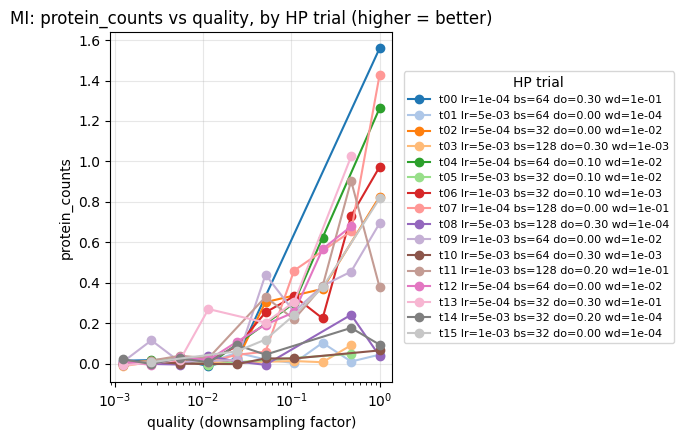

In [53]:
# MI curve for protein_counts only: one line per HP trial, x = quality (log), y = MI.
import matplotlib.pyplot as plt

mi_col = 'mi_protein_counts'
if mi_col not in df.columns:
    print(f'{mi_col} not found — nothing to plot.')
else:
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    trial_ids = sorted(df['trial_id'].unique())
    cmap = plt.get_cmap('tab20' if len(trial_ids) > 10 else 'tab10')

    for i, tid in enumerate(trial_ids):
        sub = df[df['trial_id'] == tid].sort_values('quality')
        sub = sub[sub[mi_col].notna()]
        if sub.empty:
            continue
        cfg = sub.iloc[0]
        label = (f"t{int(tid):02d} "
                 f"lr={cfg['max_lr']:.0e} bs={int(cfg['batch_size'])} "
                 f"do={cfg['dropout']:.2f} wd={cfg['weight_decay']:.0e}")
        ax.plot(sub['quality'].values, sub[mi_col].values,
                marker='o', linewidth=1.5, color=cmap(i % cmap.N), label=label)

    ax.set_xscale('log')
    ax.set_xlabel('quality (downsampling factor)')
    ax.set_ylabel('protein_counts')
    ax.set_title('MI: protein_counts vs quality, by HP trial (higher = better)')
    ax.grid(alpha=0.3)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, title='HP trial')
    plt.tight_layout()
    plt.show()

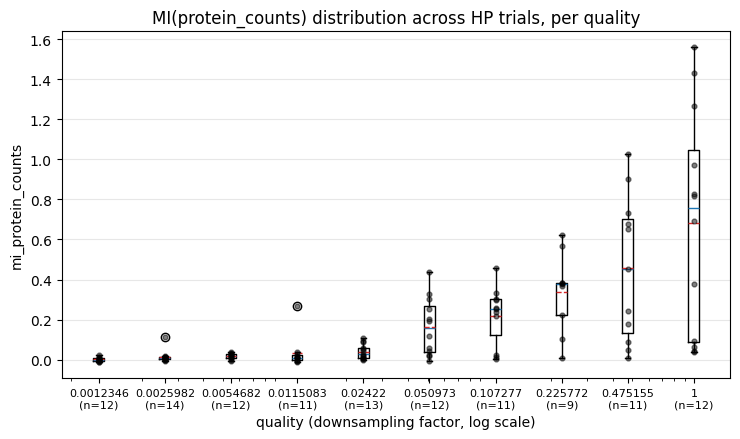

In [54]:
# Box plot: distribution of mi_protein_counts across HP trials, one box per quality.
# x-axis is true log scale (positions = quality, ax.set_xscale('log')).
import matplotlib.pyplot as plt
import numpy as np

mi_col = 'mi_protein_counts'
if mi_col not in df.columns:
    print(f'{mi_col} not found — nothing to plot.')
else:
    sub = df[df[mi_col].notna()]
    qualities = sorted(sub['quality'].unique())
    data = [sub.loc[sub['quality'] == q, mi_col].values for q in qualities]
    n_per = [len(d) for d in data]

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    positions = np.array(qualities, dtype=float)
    # On a log axis, a constant linear `width` would look microscopic at small x
    # and huge at large x. Pick a constant log-space half-width (≈12%) and emit
    # asymmetric widths in linear units that map to it.
    w = 0.12
    widths = positions * (np.exp(w) - np.exp(-w)) / 2
    ax.boxplot(data, positions=positions, widths=widths,
               showmeans=True, meanline=True,
               medianprops=dict(color='C0'),
               meanprops=dict(color='C3', linestyle='--'))
    for pos, d in zip(positions, data):
        ax.scatter(np.full_like(d, pos, dtype=float), d,
                   s=12, alpha=0.5, color='k', zorder=3)

    ax.set_xscale('log')
    ax.set_xticks(positions)
    ax.set_xticklabels([f'{q:g}\n(n={n})' for q, n in zip(qualities, n_per)],
                       fontsize=8)
    ax.set_xlabel('quality (downsampling factor, log scale)')
    ax.set_ylabel('mi_protein_counts')
    ax.set_title('MI(protein_counts) distribution across HP trials, per quality')
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

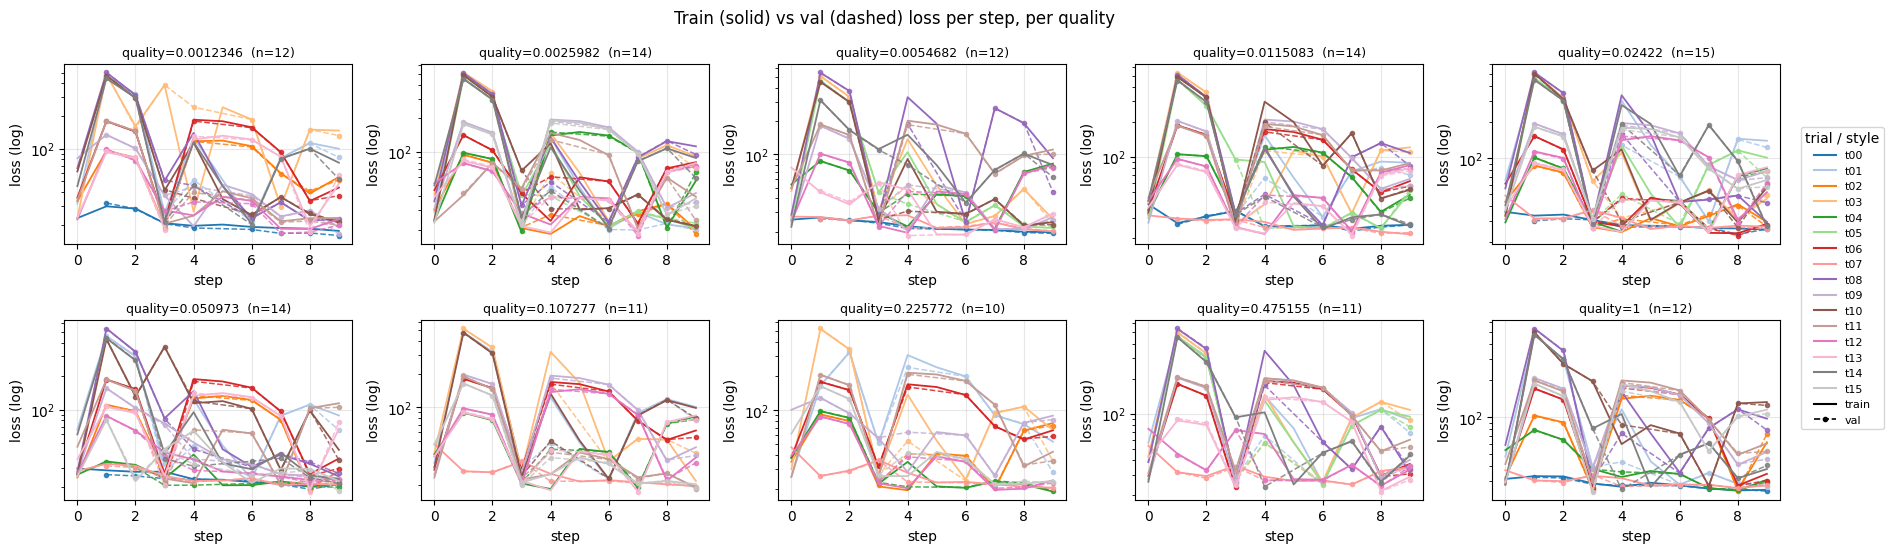

In [55]:
# Training and validation loss curves, faceted by quality.
# Solid lines = train_loss, dashed lines = val_loss; one color per trial (consistent across facets).
import matplotlib.pyplot as plt
import numpy as np

qualities_with_data = sorted({
    q for (_, _, q), c in CURVES.items()
    if (c['train'] is not None and len(c['train'])) or (c['val'] is not None and len(c['val']))
})
if not qualities_with_data:
    print('No loss curves found yet.')
else:
    trial_ids = sorted(df['trial_id'].unique())
    cmap = plt.get_cmap('tab20' if len(trial_ids) > 10 else 'tab10')
    color_of = {tid: cmap(i % cmap.N) for i, tid in enumerate(trial_ids)}

    n = len(qualities_with_data)
    ncols = min(5, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 2.8 * nrows), squeeze=False)

    for ax_idx, q in enumerate(qualities_with_data):
        ax = axes[ax_idx // ncols][ax_idx % ncols]
        n_runs = 0
        for (tid, size, qq), cur in CURVES.items():
            if qq != q:
                continue
            color = color_of.get(tid, 'k')
            if cur['train'] is not None and len(cur['train']):
                ax.plot(cur['train']['step'], cur['train']['train_loss'],
                        '-', color=color, lw=1.3, label=f't{tid:02d} train')
                n_runs += 1
            if cur['val'] is not None and len(cur['val']):
                ax.plot(cur['val']['step'], cur['val']['val_loss'],
                        '--', color=color, lw=1.1, alpha=0.85,
                        marker='o', ms=3, label=f't{tid:02d} val')
        ax.set_yscale('log')
        ax.set_title(f'quality={q:g}  (n={n_runs})', fontsize=9)
        ax.set_xlabel('step')
        ax.set_ylabel('loss (log)')
        ax.grid(alpha=0.3)

    for j in range(len(qualities_with_data), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')

    # One shared legend outside the grid; style line = train/val, color = trial.
    handles = [plt.Line2D([0], [0], color=color_of[tid], lw=1.5,
                          label=f't{tid:02d}') for tid in trial_ids]
    handles += [
        plt.Line2D([0], [0], color='k', lw=1.5, label='train'),
        plt.Line2D([0], [0], color='k', lw=1.2, ls='--', marker='o', ms=3, label='val'),
    ]
    fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
               fontsize=8, title='trial / style')
    plt.suptitle('Train (solid) vs val (dashed) loss per step, per quality')
    plt.tight_layout()
    plt.show()

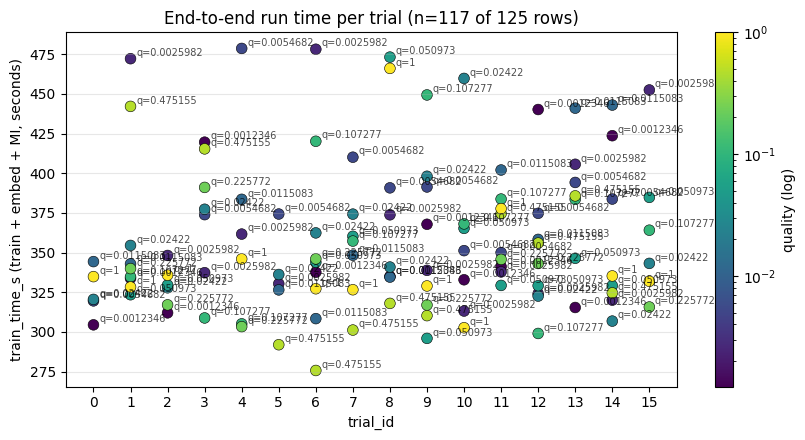

In [56]:
# Total end-to-end time per run (train + embed + MI), from result.json's train_time_s.
# Scatter: x = trial_id (for per-trial comparison), y = seconds, color = quality (log).
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

timed = df[df['train_time_s'].notna()].copy() if 'train_time_s' in df.columns else df.iloc[0:0]
if timed.empty:
    print('No train_time_s values yet.')
else:
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    norm = mcolors.LogNorm(vmin=timed['quality'].min(), vmax=timed['quality'].max())
    sc = ax.scatter(timed['trial_id'], timed['train_time_s'],
                    c=timed['quality'], cmap='viridis', norm=norm, s=60,
                    edgecolors='k', linewidths=0.4)
    for _, r in timed.iterrows():
        ax.annotate(f"q={r['quality']:g}", (r['trial_id'], r['train_time_s']),
                    xytext=(4, 2), textcoords='offset points', fontsize=7, alpha=0.7)
    ax.set_xlabel('trial_id')
    ax.set_ylabel('train_time_s (train + embed + MI, seconds)')
    ax.set_title(f'End-to-end run time per trial (n={len(timed)} of {len(df)} rows)')
    ax.grid(alpha=0.3, axis='y')
    ax.set_xticks(sorted(timed['trial_id'].unique()))
    cbar = fig.colorbar(sc, ax=ax, label='quality (log)')
    plt.tight_layout()
    plt.show()

    print('\nSummary of train_time_s (seconds):')
    print(timed['train_time_s'].describe().round(1).to_string())
    print('\nMean per trial:')
    print(timed.groupby('trial_id')['train_time_s'].mean().round(1).to_string())
    print('\nMean per quality:')
    print(timed.groupby('quality')['train_time_s'].mean().round(1).to_string())